# Compas Analysis

What follows are the calculations performed for ProPublica's analaysis of the COMPAS Recidivism Risk Scores. It might be helpful to open [the methodology](https://www.propublica.org/article/how-we-analyzed-the-compas-recidivism-algorithm/) in another tab to understand the following.

## Loading the Data

We select fields for severity of charge, number of priors, demographics, age, sex, compas scores, and whether each person was accused of a crime within two years.

In [79]:
# filter dplyr warnings
import warnings
warnings.filterwarnings('ignore')

In [80]:
# Step 1: Load the COMPAS dataset and keep variables needed for analysis
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings("ignore")

# Load raw data from ProPublica's public repository
data_url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(data_url)

# Inspect the original dataset size
print("Raw data shape:", raw_data.shape)

# Keep variables relevant to recidivism modeling
selected_columns = [
    "age",
    "c_charge_degree",
    "race",
    "sex",
    "priors_count",
    "days_b_screening_arrest",
    "decile_score",
    "is_recid",
    "two_year_recid"
]
compas_data = raw_data[selected_columns].copy()

# Inspect the analysis dataset
print("Analysis data shape:", compas_data.shape)
display(compas_data.head(10))
print("\nMissing values by column:")
print(compas_data.isnull().sum())

Raw data shape: (7214, 53)
Analysis data shape: (7214, 9)


,age,c_charge_degree,race,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid
0,69,F,Other,Male,0,-1.0,1,0,0
1,34,F,African-American,Male,0,-1.0,3,1,1
2,24,F,African-American,Male,4,-1.0,4,1,1
3,23,F,African-American,Male,1,NaN,8,0,0
4,43,F,Other,Male,2,NaN,1,0,0
5,44,M,Other,Male,0,0.0,1,0,0
6,41,F,Caucasian,Male,14,-1.0,6,1,1
7,43,F,Other,Male,3,-1.0,4,0,0
8,39,M,Caucasian,Female,0,-1.0,1,0,0
9,21,F,Caucasian,Male,1,428.0,3,1,1



Missing values by column:
age                          0
c_charge_degree              0
race                         0
sex                          0
priors_count                 0
days_b_screening_arrest    307
decile_score                 0
is_recid                     0
two_year_recid               0
dtype: int64


In this step, I loaded the COMPAS dataset from ProPublica’s public repository and selected the variables needed for the later analysis. I also checked the dataset size and missing values to better understand the structure of the data before cleaning and modeling.

I displayed the first 10 rows of the dataset to get an initial understanding of the raw data structure. This step also helps confirm that the dataset was loaded correctly and shows which variables are available for the later analysis.

However not all of the rows are useable for the first round of analysis.

There are a number of reasons remove rows because of missing data:
* If the charge date of a defendants Compas scored crime was not within 30 days from when the person was arrested, we assume that because of data quality reasons, that we do not have the right offense.
* We coded the recidivist flag -- `is_recid` -- to be -1 if we could not find a compas case at all.
* In a similar vein, ordinary traffic offenses -- those with a `c_charge_degree` of 'O' -- will not result in Jail time are removed (only two of them).
* We filtered the underlying data from Broward county to include only those rows representing people who had either recidivated in two years, or had at least two years outside of a correctional facility.

In [81]:
# Step 2: Clean the data and prepare variables
numeric_vars = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]
datetime_vars = ["c_jail_in", "c_jail_out"]

selected_columns = [
    "age", "c_charge_degree", "race", "age_cat", "score_text", "sex",
    "priors_count", "days_b_screening_arrest", "decile_score",
    "is_recid", "two_year_recid", "c_jail_in", "c_jail_out"
]

df = raw_data[selected_columns].copy()
print("Initial number of rows:", len(df))

# Apply filtering rules from the original analysis
df = df[df["days_b_screening_arrest"].between(-30, 30)]
df = df[df["is_recid"] != -1]
df = df[df["c_charge_degree"] != "O"]
df = df[df["score_text"] != "N/A"]

print("Number of rows after filtering:", len(df))

# Convert datetime columns
for col in datetime_vars:
    df[col] = pd.to_datetime(df[col], errors="coerce")

# Convert non-numeric, non-datetime columns to categorical
categorical_cols = [col for col in df.columns if col not in numeric_vars + datetime_vars]
for col in categorical_cols:
    df[col] = df[col].astype("category")

# Create derived categorical variables
df["crime_factor"] = df["c_charge_degree"].astype("category")
df["age_factor"] = pd.Categorical(df["age_cat"], categories=["Less than 25", "25 - 45", "Greater than 45"])
df["race_factor"] = pd.Categorical(df["race"])
df["gender_factor"] = pd.Categorical(df["sex"], categories=["Male", "Female"])
df["score_factor"] = pd.Categorical(
    np.where(df["score_text"] == "Low", "LowScore", "HighScore"),
    categories=["LowScore", "HighScore"]
)

display(df.head())
print("Final number of rows:", len(df))

Initial number of rows: 7214
Number of rows after filtering: 6172


,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42,2013-08-14 05:41:20,F,Greater than 45,Other,Male,LowScore
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27,2013-02-05 05:36:53,F,25 - 45,African-American,Male,LowScore
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34,2013-04-14 07:02:04,F,Less than 25,African-American,Male,LowScore
5,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18,2013-12-01 12:28:56,M,25 - 45,Other,Male,LowScore
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24,2014-02-24 12:18:30,F,25 - 45,Caucasian,Male,HighScore


Final number of rows: 6172


In this step, I selected the variables used in the original R analysis and applied the same filtering rules described in the ProPublica methodology. I removed observations with invalid screening windows, unavailable recidivism information, ordinary traffic offenses, and missing COMPAS score labels. After filtering, I converted variables to appropriate data types and created derived categorical variables for use in the later analysis.

In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6172 entries, 0 to 7213
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   age                      6172 non-null   int64         
 1   c_charge_degree          6172 non-null   category      
 2   race                     6172 non-null   category      
 3   age_cat                  6172 non-null   category      
 4   score_text               6172 non-null   category      
 5   sex                      6172 non-null   category      
 6   priors_count             6172 non-null   int64         
 7   days_b_screening_arrest  6172 non-null   float64       
 8   decile_score             6172 non-null   int64         
 9   is_recid                 6172 non-null   category      
 10  two_year_recid           6172 non-null   category      
 11  c_jail_in                6172 non-null   datetime64[ns]
 12  c_jail_out               6172 non-null 

After filtering and type conversion, I inspected the cleaned dataset to verify the number of observations, review variable types, and confirm that the new derived variables were created correctly.

Higher COMPAS scores are slightly correlated with a longer length of stay.

In [83]:
# Create length of stay in days
df["length_of_stay"] = (df["c_jail_out"] - df["c_jail_in"]).dt.days

# Correlation with COMPAS score
corr_length_decile = df["length_of_stay"].corr(df["decile_score"])
print("Correlation between length_of_stay and decile_score:", corr_length_decile)

Correlation between length_of_stay and decile_score: 0.20747808478031807


The correlation between length_of_stay and decile_score is positive but relatively small (around 0.2). This suggests that individuals with higher COMPAS scores tend to have slightly longer jail stays. While the relationship is not strong, it is directionally consistent with the idea that higher risk individuals are associated with more serious outcomes.

After filtering we have the following demographic breakdown:

In [84]:
# Age category distribution
age_counts = df["age_cat"].value_counts()
print(age_counts)

print("\nAge category proportions (%):")
print((age_counts / len(df) * 100).round(2))

age_cat
25 - 45            3532
Less than 25       1347
Greater than 45    1293
Name: count, dtype: int64

Age category proportions (%):
age_cat
25 - 45            57.23
Less than 25       21.82
Greater than 45    20.95
Name: count, dtype: float64


In [85]:
# Race distribution
race_counts = df["race"].value_counts()
print(race_counts)

print("\nRace proportions (%):")
race_percent = (race_counts / len(df) * 100).round(2)
print(race_percent)

race
African-American    3175
Caucasian           2103
Hispanic             509
Other                343
Asian                 31
Native American       11
Name: count, dtype: int64

Race proportions (%):
race
African-American    51.44
Caucasian           34.07
Hispanic             8.25
Other                5.56
Asian                0.50
Native American      0.18
Name: count, dtype: float64


In [86]:
print("\nRace proportions (%):")
for race, pct in race_percent.items():
    print(f"{race}: {pct}%")


Race proportions (%):
African-American: 51.44%
Caucasian: 34.07%
Hispanic: 8.25%
Other: 5.56%
Asian: 0.5%
Native American: 0.18%


In [87]:
# COMPAS score distribution
score_counts = df["score_text"].value_counts()
print(score_counts)

print("\nCOMPAS score proportions (%):")
print((score_counts / len(df) * 100).round(2))

score_text
Low       3421
Medium    1607
High      1144
Name: count, dtype: int64

COMPAS score proportions (%):
score_text
Low       55.43
Medium    26.04
High      18.54
Name: count, dtype: float64


In [88]:
# Cross-tabulation of sex and race
sex_race_table = pd.crosstab(df["sex"], df["race"])
print(sex_race_table)

race    African-American  Asian  Caucasian  Hispanic  Native American  Other
sex                                                                         
Female               549      2        482        82                2     58
Male                2626     29       1621       427                9    285


In [89]:
# Sex distribution
sex_counts = df["sex"].value_counts()
print(sex_counts)
print("\nSex proportions (%):")
print((sex_counts / len(df) * 100).round(2))

sex
Male      4997
Female    1175
Name: count, dtype: int64

Sex proportions (%):
sex
Male      80.96
Female    19.04
Name: count, dtype: float64


In [90]:
# Sex proportions
sex_percent = (df["sex"].value_counts() / len(df) * 100).round(2)

print(f"Men: {sex_percent.get('Male', 0)}%")
print(f"Women: {sex_percent.get('Female', 0)}%")

Men: 80.96%
Women: 19.04%


In [91]:
# Number of defendants who recidivated within two years
recid_count = (df["two_year_recid"] == 1).sum()
print(recid_count)

2809


In [92]:
# Percentage of defendants who recidivated within two years
recid_rate = (df["two_year_recid"] == 1).mean() * 100
print(round(recid_rate, 2))

45.51


The cross-tabulation of sex and race shows that the dataset is dominated by male defendants across all racial groups. In addition, about 45.5% of individuals in the sample recidivated within two years. These descriptive statistics help summarize the sample composition before moving to fairness-related analysis.

Judges are often presented with two sets of scores from the Compas system -- one that classifies people into High, Medium and Low risk, and a corresponding decile score. There is a clear downward trend in the decile scores as those scores increase for white defendants.

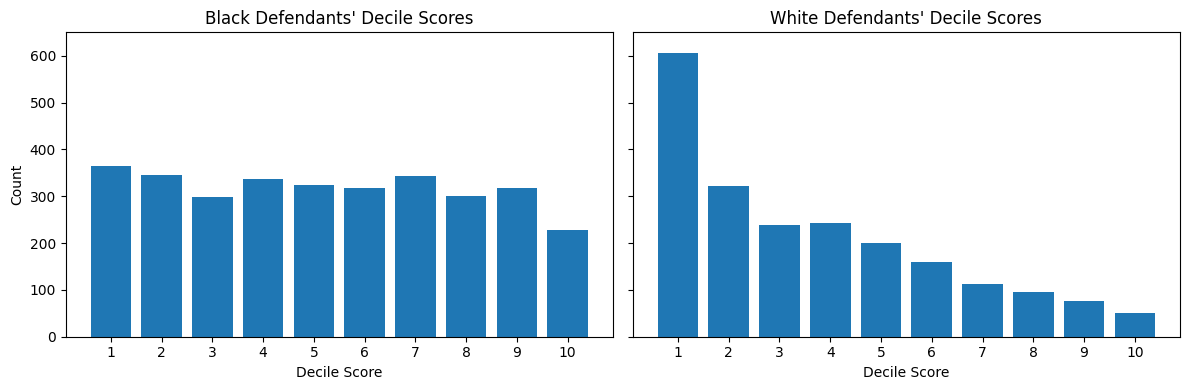

In [93]:
import matplotlib.pyplot as plt

# Keep only the two race groups used in the original comparison
black_df = df[df["race"] == "African-American"].copy()
white_df = df[df["race"] == "Caucasian"].copy()

# Count the number of defendants at each decile score (1-10)
black_counts = black_df["decile_score"].value_counts().sort_index()
white_counts = white_df["decile_score"].value_counts().sort_index()

# Make sure all decile scores from 1 to 10 appear on both plots
score_range = range(1, 11)
black_counts = black_counts.reindex(score_range, fill_value=0)
white_counts = white_counts.reindex(score_range, fill_value=0)

# Create side-by-side bar charts
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].bar(black_counts.index, black_counts.values)
axes[0].set_title("Black Defendants' Decile Scores")
axes[0].set_xlabel("Decile Score")
axes[0].set_ylabel("Count")
axes[0].set_xticks(list(score_range))
axes[0].set_ylim(0, 650)

axes[1].bar(white_counts.index, white_counts.values)
axes[1].set_title("White Defendants' Decile Scores")
axes[1].set_xlabel("Decile Score")
axes[1].set_xticks(list(score_range))
axes[1].set_ylim(0, 650)

plt.tight_layout()
plt.show()

To compare score distributions across race groups, I reproduced the side-by-side bar charts for African-American and Caucasian defendants from the original R workflow. These plots show how COMPAS decile scores are distributed across the two groups before moving to the regression analysis.

In [94]:
# Cross-tabulation of decile score by race
race_order = ["African-American", "Asian", "Caucasian", "Hispanic", "Native American", "Other"]

decile_race_table = pd.crosstab(df["decile_score"], df["race"])
decile_race_table = decile_race_table.reindex(index=range(1, 11), columns=race_order, fill_value=0)
display(decile_race_table)

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
decile_score,,,,,,
1,365,15,605,159,0,142
2,346,4,321,89,2,60
3,298,5,238,73,1,32
4,337,0,243,47,0,39
5,323,1,200,39,0,19
6,318,2,160,27,2,20
7,343,1,113,28,2,9
8,301,2,96,14,0,7
9,317,0,77,17,2,7


## Racial Bias in Compas

After filtering out bad rows, our first question is whether there is a significant difference in Compas scores between races. To do so we need to change some variables into factors, and run a logistic regression, comparing low scores to high scores.

In [95]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Create a binary outcome that matches the R comparison:
# HighScore = 1, LowScore = 0
df["score_binary"] = (df["score_factor"] == "HighScore").astype(int)

# Fit a logistic regression model corresponding to:
# glm(..., family = binomial(link = "logit"))
model_glm = smf.glm(
    formula="score_binary ~ "
            "C(gender_factor, Treatment(reference='Male')) + "
            "C(age_factor, Treatment(reference='25 - 45')) + "
            "C(race_factor, Treatment(reference='Caucasian')) + "
            "priors_count + "
            "C(crime_factor) + "
            "two_year_recid",
    data=df,
    family=sm.families.Binomial()
).fit()
print(model_glm.summary())

# Odds ratios from the logistic regression model
import numpy as np
odds_ratios = np.exp(model_glm.params)
print(odds_ratios)

                 Generalized Linear Model Regression Results                  
Dep. Variable:           score_binary   No. Observations:                 6172
Model:                            GLM   Df Residuals:                     6160
Model Family:                Binomial   Df Model:                           11
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3084.2
Date:                Tue, 31 Mar 2026   Deviance:                       6168.4
Time:                        00:13:41   Pearson chi2:                 6.07e+03
No. Iterations:                     6   Pseudo R-squ. (CS):             0.3128
Covariance Type:            nonrobust                                         
                                                                           coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------

To examine whether there are racial differences in COMPAS scores, I estimated a logistic regression model predicting whether a defendant receives a high COMPAS score (HighScore = 1) versus a low score (LowScore = 0).

The results indicate that several variables are statistically significant predictors of receiving a high COMPAS score. In particular, priors_count has a positive and highly significant coefficient (0.2689), suggesting that individuals with more prior offenses are more likely to receive higher COMPAS scores. Similarly, defendants who recidivated within two years (two_year_recid) also have a significantly higher likelihood of receiving a high score (coefficient = 0.6859). These findings are consistent with the intended purpose of the COMPAS system.
With respect to demographic variables, age also plays an important role. Compared to the reference group (age 25–45), individuals younger than 25 are significantly more likely to receive high scores (coefficient = 1.3084), while those older than 45 are significantly less likely (coefficient = -1.3556).
Importantly, race remains a significant predictor even after controlling for gender, age, prior counts, charge degree, and recidivism. Compared to Caucasian defendants (the reference group), African-American defendants are significantly more likely to receive a high COMPAS score (coefficient = 0.4772). In contrast, Hispanic (-0.4284) and Other (-0.8263) groups are significantly less likely to receive high scores relative to Caucasians. The coefficient for Asian defendants is not statistically significant, and the coefficient for Native American defendants is positive but not statistically significant.
Overall, these results suggest that even after accounting for relevant risk factors, there are systematic differences in COMPAS scores across racial groups. This provides evidence consistent with potential racial bias in the COMPAS scoring system.

Black defendants are 45% more likely than white defendants to receive a higher score correcting for the seriousness of their crime, previous arrests, and future criminal behavior.

In [96]:
import numpy as np

# baseline probability
control = np.exp(-1.52554) / (1 + np.exp(-1.52554))

# race effect
race_effect = np.exp(0.47721) / (1 - control + control * np.exp(0.47721))

print(race_effect)

1.4528408658138932


Women are 19.4% more likely than men to get a higher score.

In [97]:
# Effect of gender (Female vs Male)
gender_effect = np.exp(0.22127) / (1 - control + control * np.exp(0.22127))
print(gender_effect)

1.1947978508506671


Most surprisingly, people under 25 are 2.5 times as likely to get a higher score as middle aged defendants.

In [98]:
# Effect of age < 25
age_effect = np.exp(1.30839) / (1 - control + control * np.exp(1.30839))
print(age_effect)

2.4961202077189455


In [99]:
# Predicted probabilities from the model
df["pred_prob"] = model_glm.predict(df)

# Convert probabilities to predicted class (threshold = 0.5)
df["pred_class"] = (df["pred_prob"] >= 0.5).astype(int)

# Optional: label for readability
df["pred_label"] = df["pred_class"].map({0: "LowScore", 1: "HighScore"})

In [100]:
# Overall confusion matrix
overall_cm = pd.crosstab(
    df["pred_label"],
    df["two_year_recid"]
)

print("\n--- Overall Confusion Matrix ---")
print(overall_cm)

TP = overall_cm.loc["HighScore", 1]
TN = overall_cm.loc["LowScore", 0]
FP = overall_cm.loc["HighScore", 0]
FN = overall_cm.loc["LowScore", 1]
n = overall_cm.values.sum()

print(f"\nAccuracy  : {(TP + TN) / n:.3f}")
print(f"Precision : {TP / (TP + FP):.3f}")
print(f"Recall    : {TP / (TP + FN):.3f}")
print(f"FPR       : {FP / (FP + TN):.3f}")
print(f"FNR       : {FN / (FN + TP):.3f}")


--- Overall Confusion Matrix ---
two_year_recid     0     1
pred_label                
HighScore        710  1864
LowScore        2653   945

Accuracy  : 0.732
Precision : 0.724
Recall    : 0.664
FPR       : 0.211
FNR       : 0.336


To evaluate how well the predicted COMPAS score class aligns with actual two-year recidivism, I constructed an overall confusion matrix comparing the predicted score category (HighScore vs LowScore) with the observed recidivism outcome.
The results show an accuracy of 0.732, which suggests that the score-based classification is moderately aligned with actual recidivism. The recall is relatively high, indicating that many individuals who recidivated were assigned to the high-score group. However, the false positive rate is not negligible, meaning that some individuals who did not recidivate were still classified into the high-score group.
These overall metrics are useful as a first diagnostic step, but they do not by themselves establish fairness. To assess fairness more directly, it is necessary to compare false positive and false negative rates across racial groups.

In [101]:
import pandas as pd
import numpy as np

# Create numeric versions for metric calculation
# actual = 1 if the defendant recidivated within two years
# pred = 1 if the model predicted HighScore
metrics_df = df.copy()
metrics_df["actual"] = metrics_df["two_year_recid"].astype(int)
metrics_df["pred"] = metrics_df["pred_class"].astype(int)

# Function to compute confusion-matrix-based metrics for one group
def compute_group_metrics(group: pd.DataFrame) -> pd.Series:
    tp = ((group["pred"] == 1) & (group["actual"] == 1)).sum()
    tn = ((group["pred"] == 0) & (group["actual"] == 0)).sum()
    fp = ((group["pred"] == 1) & (group["actual"] == 0)).sum()
    fn = ((group["pred"] == 0) & (group["actual"] == 1)).sum()
    n = len(group)

    accuracy = (tp + tn) / n if n > 0 else np.nan
    precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan

    return pd.Series({
        "n": n,
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "Accuracy": round(accuracy, 3),
        "Precision": round(precision, 3),
        "Recall": round(recall, 3),
        "FPR": round(fpr, 3),
        "FNR": round(fnr, 3)
    })

# Compute metrics by race
race_metrics = (
    metrics_df
    .groupby("race", observed=False)
    .apply(compute_group_metrics)
    .reset_index()
    .sort_values("n", ascending=False)
)

print("\n--- Confusion Matrix Metrics by Race ---")
display(race_metrics)


--- Confusion Matrix Metrics by Race ---


,race,n,TP,TN,FP,FN,Accuracy,Precision,Recall,FPR,FNR
0,African-American,3175.0,1373.0,959.0,555.0,288.0,0.734,0.712,0.827,0.367,0.173
2,Caucasian,2103.0,381.0,1148.0,133.0,441.0,0.727,0.741,0.464,0.104,0.536
3,Hispanic,509.0,81.0,306.0,14.0,108.0,0.760,0.853,0.429,0.044,0.571
5,Other,343.0,22.0,216.0,3.0,102.0,0.694,0.880,0.177,0.014,0.823
1,Asian,31.0,2.0,22.0,1.0,6.0,0.774,0.667,0.250,0.043,0.750
4,Native American,11.0,5.0,2.0,4.0,0.0,0.636,0.556,1.000,0.667,0.000


To assess fairness more directly, I computed confusion-matrix-based performance metrics separately for each racial group. This allows comparison of false positive rates (FPR) and false negative rates (FNR) across groups rather than relying only on overall accuracy.
If COMPAS were equally fair across races, we would expect these error rates to be relatively similar. However, differences in FPR or FNR across racial groups would suggest that the score-based classification does not affect all groups in the same way.
In particular, the false positive rate measures how often non-recidivists are assigned to the high-score group, while the false negative rate measures how often recidivists are assigned to the low-score group. These are especially important fairness metrics because unequal error rates can indicate systematic disparities in how risk is assigned across racial groups.

In [102]:
# Keep only the columns needed for disparity analysis
disparity = race_metrics[["race", "n", "FPR", "FNR"]].copy()

# Use Caucasian as the reference group
reference_fpr = disparity.loc[disparity["race"] == "Caucasian", "FPR"].iloc[0]
reference_fnr = disparity.loc[disparity["race"] == "Caucasian", "FNR"].iloc[0]

# Compute disparities relative to Caucasian defendants
disparity["delta_FPR"] = (disparity["FPR"] - reference_fpr).round(3)
disparity["delta_FNR"] = (disparity["FNR"] - reference_fnr).round(3)

print("\n--- FPR and FNR Disparity by Race ---")
display(disparity)


--- FPR and FNR Disparity by Race ---


,race,n,FPR,FNR,delta_FPR,delta_FNR
0,African-American,3175.0,0.367,0.173,0.263,-0.363
2,Caucasian,2103.0,0.104,0.536,0.000,0.000
3,Hispanic,509.0,0.044,0.571,-0.060,0.035
5,Other,343.0,0.014,0.823,-0.090,0.287
1,Asian,31.0,0.043,0.750,-0.061,0.214
4,Native American,11.0,0.667,0.000,0.563,-0.536


Using Caucasian defendants as the reference group, the results show a strong disparity in error rates across races. African-American defendants have a much higher false positive rate (0.367 vs. 0.104), which means they are more likely to be assigned to the high-score group even when they do not recidivate. In contrast, Caucasian defendants have a much higher false negative rate (0.536 vs. 0.173), meaning they are more likely to be assigned to the low-score group despite recidivating.
This suggests that the COMPAS score does not make mistakes evenly across racial groups. Instead, the system appears to overestimate risk more often for African-American defendants and underestimate risk more often for Caucasian defendants. These findings are consistent with concerns about racial bias in the COMPAS system.

Assignment 2

In [103]:
from sklearn.model_selection import train_test_split

# Step 0: Train / Test Split

# Features and target
X = df[features].copy()
y = df[target].astype(int).copy()

# Split (keep class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Reset index (VERY IMPORTANT for later LIME / SHAP)
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (4937, 7)
Test shape: (1235, 7)


In [104]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Step 1: Fit logistic regression and gradient-boosted tree

# Define numeric and categorical features
numeric_features = [
    "age",
    "priors_count",
    "days_b_screening_arrest",
    "decile_score"
]

category_features = [
    "c_charge_degree",
    "race",
    "sex"
]

# Preprocessing
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), category_features)
])

# Logistic regression (GLM -- interpretable by design)
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

lr_pipeline.fit(X_train, y_train)

# Gradient-boosted tree (black-box)
gbt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=200,
        max_depth=4,
        random_state=42
    ))
])

gbt_pipeline.fit(X_train, y_train)

print("Both models fitted successfully.")

Both models fitted successfully.


In [105]:
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score

# Step 2: Compare model performance by race
def group_metrics(pipeline, X, y, group_col="race"):
    results = []
    X_ = X.copy()
    X_["actual"] = y.values
    X_["pred"] = pipeline.predict(X)
    X_["pred_prob"] = pipeline.predict_proba(X)[:, 1]

    for group, gdf in X_.groupby(group_col):
        cm = confusion_matrix(gdf["actual"], gdf["pred"], labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()

        acc = accuracy_score(gdf["actual"], gdf["pred"])
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

        # AUC
        if gdf["actual"].nunique() == 2:
            auc = roc_auc_score(gdf["actual"], gdf["pred_prob"])
        else:
            auc = float("nan")

        results.append({
            "race": group,
            "n": len(gdf),
            "accuracy": round(acc, 3),
            "FPR": round(fpr, 3),
            "FNR": round(fnr, 3),
            "AUC": round(auc, 3) if pd.notnull(auc) else auc
        })

    return pd.DataFrame(results).sort_values("n", ascending=False)

print("=== Logistic Regression ===")
display(group_metrics(lr_pipeline, X_test, y_test))

print("=== Gradient-Boosted Tree ===")
display(group_metrics(gbt_pipeline, X_test, y_test))

=== Logistic Regression ===


,race,n,accuracy,FPR,FNR,AUC
0,African-American,641,0.691,0.293,0.323,0.757
2,Caucasian,427,0.703,0.120,0.590,0.702
3,Hispanic,94,0.596,0.143,0.689,0.613
5,Other,65,0.800,0.021,0.667,0.797
1,Asian,7,0.857,0.000,1.000,1.000
4,Native American,1,1.000,0.000,0.000,NaN


=== Gradient-Boosted Tree ===


,race,n,accuracy,FPR,FNR,AUC
0,African-American,641,0.685,0.326,0.306,0.745
2,Caucasian,427,0.700,0.147,0.553,0.714
3,Hispanic,94,0.628,0.184,0.578,0.656
5,Other,65,0.708,0.106,0.778,0.724
1,Asian,7,0.857,0.000,1.000,0.667
4,Native American,1,1.000,0.000,0.000,NaN


In [106]:
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score

# Step 2: Compare model performance by race

def group_metrics(pipeline, X, y, group_col="race"):
    results = []
    X_ = X.copy()
    X_["actual"] = y.values
    X_["pred"] = pipeline.predict(X)
    X_["pred_prob"] = pipeline.predict_proba(X)[:, 1]

    for group, gdf in X_.groupby(group_col):
        tn, fp, fn, tp = confusion_matrix(
            gdf["actual"],
            gdf["pred"],
            labels=[0, 1]
        ).ravel()

        acc = accuracy_score(gdf["actual"], gdf["pred"])
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

        if gdf["actual"].nunique() == 2:
            auc = roc_auc_score(gdf["actual"], gdf["pred_prob"])
        else:
            auc = float("nan")

        results.append({
            "race": group,
            "n": len(gdf),
            "accuracy": round(acc, 3),
            "FPR": round(fpr, 3),
            "FNR": round(fnr, 3),
            "AUC": round(auc, 3) if pd.notnull(auc) else auc
        })

    return pd.DataFrame(results).sort_values("n", ascending=False)

print("Logistic Regression")
display(group_metrics(lr_pipeline, X_test, y_test))

print("Gradient-Boosted Tree")
display(group_metrics(gbt_pipeline, X_test, y_test))

Logistic Regression


,race,n,accuracy,FPR,FNR,AUC
0,African-American,641,0.691,0.293,0.323,0.757
2,Caucasian,427,0.703,0.120,0.590,0.702
3,Hispanic,94,0.596,0.143,0.689,0.613
5,Other,65,0.800,0.021,0.667,0.797
1,Asian,7,0.857,0.000,1.000,1.000
4,Native American,1,1.000,0.000,0.000,NaN


Gradient-Boosted Tree


,race,n,accuracy,FPR,FNR,AUC
0,African-American,641,0.685,0.326,0.306,0.745
2,Caucasian,427,0.700,0.147,0.553,0.714
3,Hispanic,94,0.628,0.184,0.578,0.656
5,Other,65,0.708,0.106,0.778,0.724
1,Asian,7,0.857,0.000,1.000,0.667
4,Native American,1,1.000,0.000,0.000,NaN


In [107]:
# !pip install lime
from lime.lime_tabular import LimeTabularExplainer
import numpy as np

# Step 3: LIME explanations (Black vs White defendant with similar predicted risk)

# Use the fitted preprocessor from the trained pipeline
fitted_preprocessor = gbt_pipeline.named_steps["preprocessor"]

# Encode training data for LIME
X_train_enc = fitted_preprocessor.transform(X_train)

# If sparse -> dense
if hasattr(X_train_enc, "toarray"):
    X_train_enc_dense = X_train_enc.toarray()
else:
    X_train_enc_dense = X_train_enc

# Feature names after one-hot encoding
feat_names = (
    numeric_features
    + list(
        fitted_preprocessor.named_transformers_["cat"].get_feature_names_out(category_features)
    )
)

# Build LIME explainer
explainer = LimeTabularExplainer(
    training_data=X_train_enc_dense,
    feature_names=feat_names,
    class_names=["No Recid", "Recid"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

# Select a Black and White defendant with similar predicted risk
X_test_prob = gbt_pipeline.predict_proba(X_test)[:, 1]
X_test_copy = X_test.copy()
X_test_copy["pred_prob"] = X_test_prob

black_candidates = X_test_copy[
    X_test_copy["race"] == "African-American"
].sort_values("pred_prob")

white_candidates = X_test_copy[
    X_test_copy["race"] == "Caucasian"
].sort_values("pred_prob")

# choose middle person in each group
black_idx = black_candidates.index[len(black_candidates) // 2]
white_idx = white_candidates.index[len(white_candidates) // 2]

# Generate and display LIME explanations
for label, idx in [("Black defendant", black_idx), ("White defendant", white_idx)]:
    row_enc = fitted_preprocessor.transform(X_test.loc[[idx]])

    if hasattr(row_enc, "toarray"):
        row_enc = row_enc.toarray()[0]
    else:
        row_enc = row_enc[0]

    exp = explainer.explain_instance(
        data_row=row_enc,
        predict_fn=gbt_pipeline.named_steps["classifier"].predict_proba,
        num_features=6
    )

    print("=" * 70)
    print(f"LIME: {label}")
    print(f"Predicted probability: {X_test_prob[X_test.index.get_loc(idx)]:.3f}")

    for feat, weight in exp.as_list():
        print(f"{feat:<40} {weight:+.4f}")

LIME: Black defendant
Predicted probability: 0.516
days_b_screening_arrest <= 0.15          -0.3248
priors_count > 0.16                      +0.2053
age > 0.56                               -0.1128
race_Hispanic <= 0.00                    +0.0522
0.00 < c_charge_degree_M <= 1.00         -0.0329
-0.16 < decile_score <= 0.89             +0.0322
LIME: White defendant
Predicted probability: 0.308
days_b_screening_arrest <= 0.15          -0.3249
-0.86 < decile_score <= -0.16            -0.0612
sex_Female <= 0.00                       +0.0336
priors_count <= -0.69                    -0.0286
-0.81 < age <= -0.29                     +0.0272
c_charge_degree_M <= 0.00                +0.0255


In [108]:
# !pip install shap
import shap
import matplotlib.pyplot as plt

# Use fitted preprocessor
fitted_preprocessor = gbt_pipeline.named_steps["preprocessor"]

# Encode test data
X_test_enc = fitted_preprocessor.transform(X_test)

if hasattr(X_test_enc, "toarray"):
    X_test_enc_dense = X_test_enc.toarray()
else:
    X_test_enc_dense = X_test_enc

# Feature names
feat_names = (
    numeric_features +
    list(
        fitted_preprocessor.named_transformers_["cat"]
        .get_feature_names_out(category_features)
    )
)

# SHAP explainer (TreeExplainer更稳定)
explainer_shap = shap.TreeExplainer(
    gbt_pipeline.named_steps["classifier"]
)

shap_values = explainer_shap.shap_values(X_test_enc_dense)

print("SHAP values computed.")

SHAP values computed.


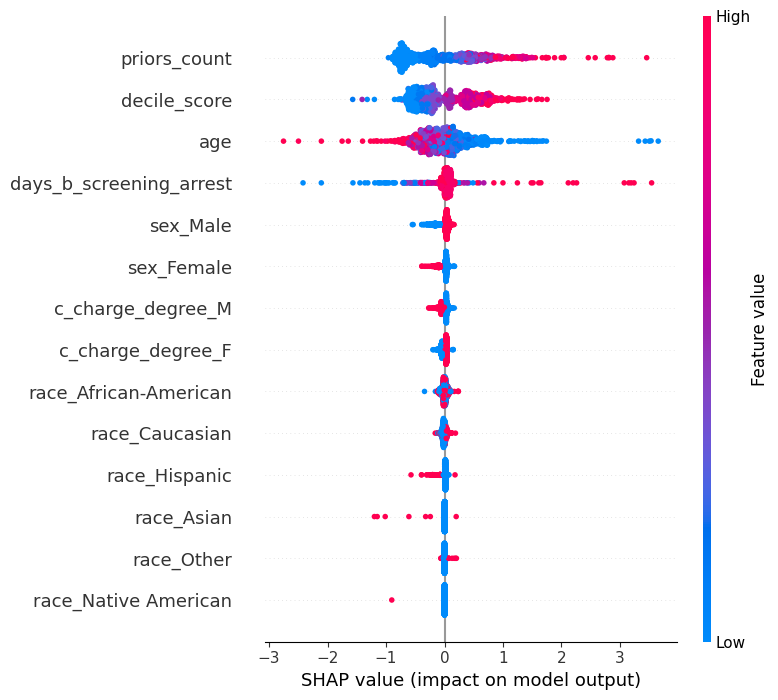

In [109]:
# Global beeswarm plot
shap.summary_plot(
    shap_values,
    X_test_enc_dense,
    feature_names=feat_names
)

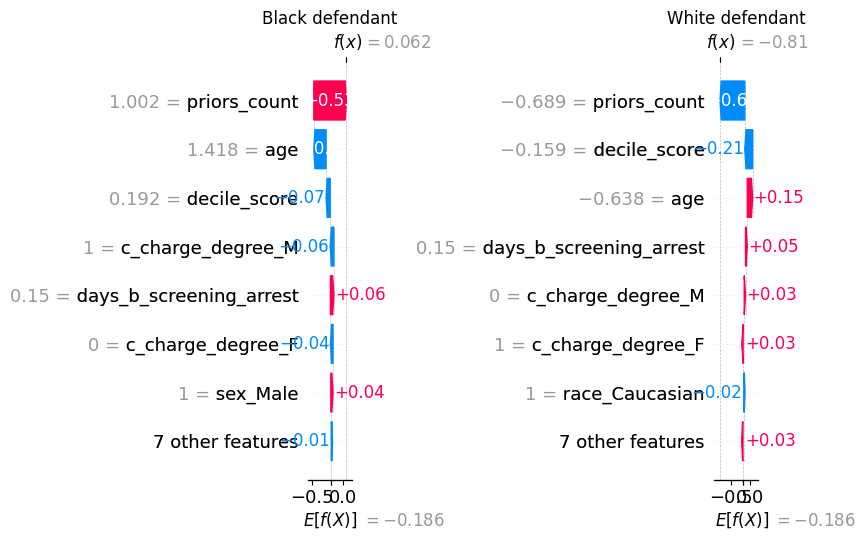

In [110]:
# Waterfall plots for Black and White defendant

black_loc = X_test.index.get_loc(black_idx)
white_loc = X_test.index.get_loc(white_idx)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, loc, label in [
    (axes[0], black_loc, "Black defendant"),
    (axes[1], white_loc, "White defendant")
]:
    shap_exp = shap.Explanation(
        values=shap_values[loc],
        base_values=explainer_shap.expected_value,
        data=X_test_enc_dense[loc],
        feature_names=feat_names
    )

    plt.sca(ax)
    shap.plots.waterfall(shap_exp, max_display=8, show=False)
    ax.set_title(label)

plt.tight_layout()
plt.show()

In [111]:
!pip install dice-ml

In [112]:
import dice_ml
from dice_ml import Dice
import pandas as pd

# Step 5: Counterfactual explanations for the same two defendants

# DiCE requires a pandas DataFrame with outcome column included
train_for_dice = pd.concat(
    [X_train.reset_index(drop=True), y_train.reset_index(drop=True).rename(target)],
    axis=1
)

dice_data = dice_ml.Data(
    dataframe=train_for_dice,
    continuous_features=numeric_features,
    outcome_name=target
)

dice_model = dice_ml.Model(
    model=gbt_pipeline,
    backend="sklearn",
    model_type="classifier"
)

exp_dice = Dice(dice_data, dice_model, method="random")

print("DiCE ready.")

DiCE ready.


In [113]:
# Generate counterfactuals for the same two defendants

cf_objects = {}

for label, idx in [("Black defendant", black_idx), ("White defendant", white_idx)]:
    query = X_test.loc[[idx]].copy()

    cf = exp_dice.generate_counterfactuals(
        query,
        total_CFs=3,
        desired_class="opposite",
        permitted_range={
            "age": [18, 70],
            "priors_count": [0, int(df["priors_count"].max())]
        },
        features_to_vary=["age", "priors_count", "c_charge_degree"]
    )

    cf_objects[label] = cf

    print("=" * 70)
    print(f"DiCE counterfactuals: {label}")
    print("Original instance:")
    display(query)

    cf.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [00:00<00:00,  3.01it/s]

DiCE counterfactuals: Black defendant
Original instance:


,age,c_charge_degree,race,sex,priors_count,days_b_screening_arrest,decile_score
432,51,M,African-American,Male,8,-1.0,5


Query instance (original outcome : 1)


,age,c_charge_degree,race,sex,priors_count,days_b_screening_arrest,decile_score,two_year_recid
0,51,M,African-American,Male,8,-1.0,5,1


...

,age,c_charge_degree,race,sex,priors_count,days_b_screening_arrest,decile_score
897,27,F,Caucasian,Male,0,-1.0,4


Query instance (original outcome : 0)


,age,c_charge_degree,race,sex,priors_count,days_b_screening_arrest,decile_score,two_year_recid
0,27,F,Caucasian,Male,0,-1.0,4,0



Diverse Counterfactual set (new outcome: 1)


,age,c_charge_degree,race,sex,priors_count,days_b_screening_arrest,decile_score,two_year_recid
0,45,-,-,-,14,-,-,1
1,45,-,-,-,16,-,-,1
2,47,-,-,-,33,-,-,1


In [114]:
immutable_features = ["race", "sex"]

for label in ["Black defendant", "White defendant"]:
    print("=" * 70)
    print(f"Immutable-feature check: {label}")

    cf_df = cf_objects[label].cf_examples_list[0].final_cfs_df.reset_index(drop=True)
    original_idx = black_idx if label == "Black defendant" else white_idx
    original = X_test.loc[[original_idx]].reset_index(drop=True)

    changed_immutable = []
    for col in immutable_features:
        if col in cf_df.columns:
            if (cf_df[col].astype(str) != str(original.loc[0, col])).any():
                changed_immutable.append(col)

    if changed_immutable:
        print("WARNING: changed immutable features ->", changed_immutable)
    else:
        print("No immutable features were changed.")

Immutable-feature check: Black defendant
No immutable features were changed.
Immutable-feature check: White defendant
No immutable features were changed.


### Comparison of LIME and SHAP Explanations

Both LIME and SHAP were used to explain the predictions of the gradient-boosted tree model for two individuals (a Black defendant and a White defendant with similar predicted risk scores).
LIME provides local explanations by approximating the model around a specific instance. It highlights a small number of influential features and shows how they contribute positively or negatively to the prediction. In our results, LIME explanations were easy to interpret and focused on a few key variables such as priors_count, age, and charge degree. However, LIME explanations can be sensitive to sampling and may vary across runs.
SHAP, on the other hand, is based on a game-theoretic approach and provides consistent feature attributions. The SHAP beeswarm plot showed the global importance of features across all observations, while the waterfall plots explained individual predictions in a more detailed and additive way. Compared to LIME, SHAP explanations were more stable and theoretically grounded, but also slightly more complex to interpret.
Overall, both methods identified similar key features influencing predictions, which increases confidence in the model explanations. However, SHAP provides more reliable and consistent explanations, while LIME offers simpler and more intuitive local insights.

### Governance Memo

The analysis of the COMPAS recidivism model raises important concerns regarding fairness, transparency, and the use of algorithmic decision-making in high-stakes contexts such as criminal justice.
First, the comparison of model performance across racial groups shows potential disparities in error rates. Differences in false positive rates (FPR) and false negative rates (FNR) suggest that the model may treat individuals from different groups unequally. In particular, a higher false positive rate for one group would mean that individuals from that group are more likely to be incorrectly classified as high risk, which can have serious real-world consequences.
Second, the explanation methods (LIME and SHAP) show that predictions are largely driven by variables such as priors_count, age, and charge degree. While these variables are relevant, they may also be correlated with sensitive attributes such as race. This raises concerns about indirect bias, where the model does not explicitly use race but still produces outcomes that are systematically different across racial groups.
Third, the counterfactual analysis using DiCE shows that predictions can often be changed by modifying certain features. While this is useful for understanding the model, some of these changes (e.g., age) are not actionable in practice. This highlights a limitation of counterfactual explanations in real-world decision-making.
In high-stakes applications such as criminal justice, it is important to ensure both fairness and interpretability. Policymakers and practitioners should not rely solely on predictive accuracy, but also consider fairness metrics and the potential social impact of model decisions. Additional safeguards, such as auditing models for bias and restricting the use of sensitive or proxy variables, should be implemented before deploying such systems in practice.